<a href="https://colab.research.google.com/github/pedroyoshikadogarcia/Checkpoint-01-Analise-de-Dados-de-Energia-SERS-02-2026/blob/main/CP1_SERS_2_Semestre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Grupo:

Eduardo Novaki Santos Coelho RM: 572649

Gabriel dos Santos Siqueira RM: 572200

Pedro Andreassa Zamai RM: 569318

Pedro Yoshikado Garcia RM: 570449

Rafael Ferreirinha Quaresma RM: 571949

Thiago Maluf Hofmann RM:569852






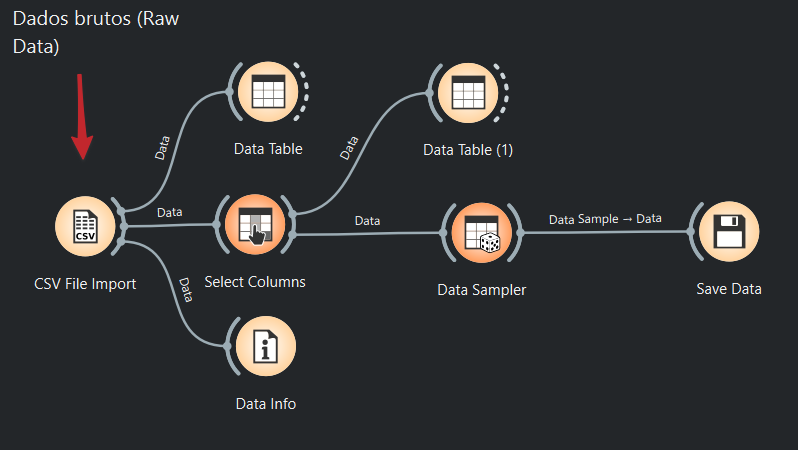

## Etapa A — Orange Data Mining

## Etapa B — Python / Pandas

In [ ]:
# Importação da biblioteca pandas, que é a ferramenta em python para manipulação, filtragem e análise de dados
import pandas as pd

## 1. Carregamento e inspeção inicial da amostra
Carregar a amostra exportada do Orange e apresentar head(), shape, info() e describe().

In [ ]:
# Carregando o arquivo CSV exportado do Orange, armazenando os dados.
dados = pd.read_csv('/content/energydata_complete.csv')

In [ ]:
# Exibindo os 5 primeiros registros do dataset para inspecionar a estrrutura inicial das colunas.
dados.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


In [ ]:
# Verificando as dimensoes do conjunto (quantidade, linhas/registros e colunas/atributos)
print(f'O número de registros do dataframe é: {dados.shape[0]}')
print(f'O número de atributos do dataframe é: {dados.shape[1]}')

O número de registros do dataframe é: 1974
O número de atributos do dataframe é: 8


In [ ]:
# Usando .info() para confirmar os tipos de dados e garantir que nao existem valores ausentes.
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Appliances  1974 non-null   int64  
 1   lights      1974 non-null   int64  
 2   T1          1974 non-null   float64
 3   RH_1        1974 non-null   float64
 4   T2          1974 non-null   float64
 5   RH_2        1974 non-null   float64
 6   T3          1974 non-null   float64
 7   RH_3        1974 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 123.5 KB


In [ ]:
# Gerando o resumo das estatisticas do dataset para entender a distruibuição dos dados de consumo e das variaveis ambientais
dados.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3
count,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000,1974.000000
mean,93.044580,3.839919,21.664703,40.219193,20.293635,40.411386,22.231615,39.209733
std,93.826149,7.937076,1.574883,3.971923,2.126958,4.037686,1.957275,3.288818
min,20.000000,0.000000,16.790000,27.733300,16.100000,24.063300,17.200000,30.133300
25%,50.000000,0.000000,20.700000,37.205825,18.790000,37.760000,20.700000,36.900000
50%,60.000000,0.000000,21.600000,39.590000,20.000000,40.433300,22.100000,38.433300
75%,100.000000,0.000000,22.600000,42.991675,21.500000,43.228325,23.290000,41.741250
max,770.000000,50.000000,26.260000,57.496700,28.917500,56.026700,29.198600,49.226700


## 2. Renomeação de colunas
Renomear Appliances para Consumo_Eletrodomesticos e simplificar o nome de pelo menos três atributos ambientais (umidade)

In [ ]:
# Renomeando os nomes das variáveis para facilitar a leitura.
dados = dados.rename(columns={'Appliances' : 'Consumo_Eletrodomesticos',
                              'RH_1' : 'Umidade_Comodo_1',
                              'RH_2' : 'Umidade_Comodo_2',
                              'RH_3' : 'Umidade_Comodo_3'})

dados.head()

,Consumo_Eletrodomesticos,lights,T1,Umidade_Comodo_1,T2,Umidade_Comodo_2,T3,Umidade_Comodo_3
0,40,0,20.8900,35.4000,17.7600,39.1633,20.2900,36.9000
1,90,10,21.8900,53.1000,21.2900,45.3600,21.6333,49.2267
2,50,0,21.3900,35.5000,17.6333,40.5300,21.6667,35.2000
3,50,0,21.3900,41.0333,23.8900,34.8400,22.0333,36.9333
4,70,0,19.9633,35.1267,16.4633,40.1267,20.0000,36.4000


## 3. Consumo máximo registrado
Determinar o maior consumo de eletrodomésticos registrado na amostra.

In [ ]:
# Identificando o pico máximo de consumo de eletrodomésticos registrado atraves do metodo .max()
maximo = dados['Consumo_Eletrodomesticos'].max()
maximo

770

## 4. Limiar de 70% e filtro de alto consumo
Calcular o limiar correspondente a 70% do valor máximo e criar um DataFrame contendo somente os registros acima desse limite.

In [ ]:
# Calculando o limite correspondente a 70% do consumo máximo e criando df_alto contendo apenas os picos de consumo
PMAX = dados['Consumo_Eletrodomesticos'].max()
P70 = 0.70 * PMAX
df_alto = dados[dados['Consumo_Eletrodomesticos'] > P70]
df_alto

,Consumo_Eletrodomesticos,lights,T1,Umidade_Comodo_1,T2,Umidade_Comodo_2,T3,Umidade_Comodo_3
352,620,0,24.3900,44.3333,25.3700,37.7360,26.7300,38.8633
427,650,0,20.8900,36.7000,18.2900,39.6633,21.2000,36.0000
453,560,30,21.3567,36.0900,19.5667,37.1633,21.6333,35.0300
616,570,10,24.8900,32.6667,23.5600,31.1400,23.6000,30.8233
696,590,30,19.8567,47.6633,18.7000,34.1000,18.4267,37.8333
744,740,20,19.5000,42.1333,18.2600,39.1967,19.8900,39.1933
916,750,30,22.4300,43.0000,21.9267,40.1333,21.2300,42.5967
993,690,10,22.5333,45.0267,22.0667,39.7900,22.3900,41.9300
1026,560,0,21.0000,38.9000,19.2900,40.2000,21.7000,37.2000
1173,580,0,21.6000,34.6267,19.5000,33.7600,22.5750,34.8725


## 5. Contagem e percentual dos registros de alto consumo
Contar os registros selecionados e calcular qual percentual da amostra eles representam.

In [ ]:
# Contando a quantidade de registros do DataFrame df_alto e calculando a proporção que o grupo representa
qtd_alto = len(df_alto)
qtd_total = len(dados)
percentual = (qtd_alto / qtd_total) * 100
print(f"Percentual: {percentual:.2f}%")

Percentual: 1.11%


## 6. Temperatura média (T1) e filtro combinado
Calcular a temperatura média de T1 e criar um segundo DataFrame com consumo acima de 70% do máximo e temperatura acima da média.

In [ ]:
# Calculando a temperatura media da variavel T1 e aplicando um filtro com duas condições: consumo eletrodomesticos
# acima de 70% do máximo e temperatura acima da média da amostra.
media_t1 = dados['T1'].mean()

df_alto_temp = dados[(dados['Consumo_Eletrodomesticos'] > P70) & (dados['T1'] > media_t1)]

print(f"Média de T1: {media_t1:.2f}°C")
print(f"Quantidade de registros com alto consumo e T1 acima da média: {len(df_alto_temp)}")

Média de T1: 21.66°C
Quantidade de registros com alto consumo e T1 acima da média: 8


## 7. Comparação entre os dois DataFrames
Comparar a quantidade de registros dos dois filtros e interpretar o efeito da inclusão da temperatura como segundo critério.

In [ ]:
# Comparando a quantidade de registros entre os dois filtros
print(f"Registros só por consumo alto: {len(df_alto)}")

print(f"Registros por consumo alto + T1 acima da média: {len(df_alto_temp)}")


Registros só por consumo alto: 22
Registros por consumo alto + T1 acima da média: 8


## Análise Interpretativa:

Ao filtrar apenas pelo consumo elevado de eletrodomésticos, obtivemos 22 registreos (1.11% da amostra).

Ao adicionar a temperatura acima da média o valor caiu para 8 registros.

O filtro da condição termica afunilou a busca, provando que nem todo pico de consumo elétrico acontece em momentos de maior aquecimento do cômodo 1. Essa análise combinada permite à equipe isolar apenas os episódios em que a alta demanda energética coincide com o aquecimento do ambiente.

## Dataset 2 - Steel Industry Energy Consumption (UCI)


In [ ]:
# Carregando o arquivo CSV exportado do Orange, armazenando os dados.
dados = pd.read_csv('/content/energydata_complete_dataset2.csv')

In [ ]:
# Renomeando os nomes das variáveis para facilitar a leitura.
dados = dados.rename(columns={'Usage_kWh' : 'Consumo_kWh',
                              'Lagging_Current_Reactive.Power_kVarh' : 'Potência_Reativa_1',
                              'Leading_Current_Reactive_Power_kVarh' : 'Potência_Reativa_2',
                              'Lagging_Current_Power_Factor' : 'Fator_Potência_1',
                              'Leading_Current_Power_Factor' : 'Fator_Potência_2'})

dados.head()

,date,Consumo_kWh,Potência_Reativa_1,Potência_Reativa_2,Fator_Potência_1,Fator_Potência_2,WeekStatus,Day_of_week,Load_Type
0,29/04/2018 07:15,2.88,3.82,0.0,60.20,100.00,Weekend,Sunday,Light_Load
1,04/10/2018 12:00,60.77,48.02,0.0,78.46,100.00,Weekday,Thursday,Maximum_Load
2,26/01/2018 11:30,120.42,59.65,0.0,89.61,100.00,Weekday,Friday,Maximum_Load
3,02/06/2018 14:30,3.13,0.00,16.6,100.00,18.53,Weekend,Saturday,Light_Load
4,07/12/2018 15:00,58.86,20.99,0.0,94.19,100.00,Weekday,Friday,Medium_Load


In [ ]:
dados.head()

,date,Consumo_kWh,Potência_Reativa_1,Potência_Reativa_2,Fator_Potência_1,Fator_Potência_2,WeekStatus,Day_of_week,Load_Type
0,29/04/2018 07:15,2.88,3.82,0.0,60.20,100.00,Weekend,Sunday,Light_Load
1,04/10/2018 12:00,60.77,48.02,0.0,78.46,100.00,Weekday,Thursday,Maximum_Load
2,26/01/2018 11:30,120.42,59.65,0.0,89.61,100.00,Weekday,Friday,Maximum_Load
3,02/06/2018 14:30,3.13,0.00,16.6,100.00,18.53,Weekend,Saturday,Light_Load
4,07/12/2018 15:00,58.86,20.99,0.0,94.19,100.00,Weekday,Friday,Medium_Load


In [ ]:
print(f"Linhas (Registros): {dados.shape[0]}")
print(f"Colunas (Atributos): {dados.shape[1]}")

Linhas (Registros): 7008
Colunas (Atributos): 9


In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                7008 non-null   object 
 1   Consumo_kWh         7008 non-null   float64
 2   Potência_Reativa_1  7008 non-null   float64
 3   Potência_Reativa_2  7008 non-null   float64
 4   Fator_Potência_1    7008 non-null   float64
 5   Fator_Potência_2    7008 non-null   float64
 6   WeekStatus          7008 non-null   object 
 7   Day_of_week         7008 non-null   object 
 8   Load_Type           7008 non-null   object 
dtypes: float64(5), object(4)
memory usage: 492.9+ KB


In [ ]:
dados.describe()

,Consumo_kWh,Potência_Reativa_1,Potência_Reativa_2,Fator_Potência_1,Fator_Potência_2
count,7008.000000,7008.000000,7008.000000,7008.000000,7008.000000
mean,27.790164,13.206839,3.803711,80.672277,84.491448
std,33.717719,16.444246,7.356412,18.869855,30.314798
min,2.450000,0.000000,0.000000,37.870000,12.710000
25%,3.200000,2.380000,0.000000,63.602500,99.710000
50%,4.570000,5.040000,0.000000,87.990000,100.000000
75%,52.107500,22.977500,1.857500,98.842500,100.000000
max,153.140000,87.700000,27.650000,100.000000,100.000000


In [ ]:
max_consumo = dados['Consumo_kWh'].max()
limiar_75 = 0.75 * max_consumo

print(f"Maior consumo registrado: {max_consumo:.2f} kWh")
print(f"Limiar de 75% do consumo máximo: {limiar_75:.2f} kWh")

Maior consumo registrado: 153.14 kWh
Limiar de 75% do consumo máximo: 114.85 kWh


In [ ]:
df_alto_consumo = dados[dados['Consumo_kWh'] > limiar_75]

qtd_alto = len(df_alto_consumo)
total_registros = len(dados)
percentual_alto = (qtd_alto / total_registros) * 100

print(f"Quantidade de registros acima do limiar: {qtd_alto}")
print(f"Percentual correspondente: {percentual_alto:.2f}%")

Quantidade de registros acima do limiar: 129
Percentual correspondente: 1.84%


In [ ]:
qtd_max_load = (df_alto_consumo['Load_Type'] == 'Maximum_Load').sum()
print(f"Registros de alto consumo classificados como 'Maximum_Load': {qtd_max_load}")

Registros de alto consumo classificados como 'Maximum_Load': 62


In [ ]:
# Definindo um limite coerente de 80.0 para eficiência baixa no Fator_Potência_1
limite_fp = 80.0

df_atencao = dados[(dados['Consumo_kWh'] > limiar_75) & (dados['Fator_Potência_1'] < limite_fp)]

print(f"Registros com consumo elevado e fator de potência abaixo de {limite_fp}: {len(df_atencao)}")

Registros com consumo elevado e fator de potência abaixo de 80.0: 0


In [ ]:
# Analisando o describe anterior, vamos ajustar o limite do fator de potência para 90.0
# para conseguir capturar os registros de consumo alto com ineficiência real
limite_fp = 90.0

df_atencao = dados[(dados['Consumo_kWh'] > limiar_75) & (dados['Fator_Potência_1'] < limite_fp)]

print(f"Quantidade de registros com consumo elevado e FP1 abaixo de {limite_fp}: {len(df_atencao)}")

Quantidade de registros com consumo elevado e FP1 abaixo de 90.0: 42


Este segundo conjunto de registros merece maior atenção da equipe de energia porque sinaliza uma ineficiência operacional crítica na planta. A ocorrência simultânea de um consumo elétrico elevado (acima de 75% do pico) com um fator de potência defasado indica uma alta circulação de potência reativa na rede. Isso sobrecarrega os transformadores e condutores, eleva as perdas térmicas por efeito Joule e deixa a fábrica exposta a pesadas multas tarifárias aplicadas pelas concessionárias de energia.

## Dataset 3 - Power Consumption of Tetouan City


In [ ]:
# Carregando o arquivo CSV exportado do Orange, armazenando os dados.
dados = pd.read_csv('/content/energydata_complete_dataset3.csv')

In [ ]:
# Renomeando os nomes das variáveis para facilitar a leitura.
dados = dados.rename(columns={'Usage_kWh' : 'Consumo_kWh',
                              'Zone 1 Power Consumption' : 'Consumo_Zona_1',
                              'Zone 2  Power Consumption' : 'Consumo_Zona_2',
                              'Zone 3  Power Consumption' : 'Consumo_Zona_3'})

dados.head()

,Temperature,Humidity,Wind Speed,Consumo_Zona_1,Consumo_Zona_2,Consumo_Zona_3
0,22.76,29.73,0.085,32985.1,19396.7,17623.3
1,15.92,54.44,0.085,34737.6,29803.0,14417.3
2,15.08,57.23,0.076,27894.7,20808.5,16458.8
3,12.42,72.30,0.081,42476.9,23634.1,25089.7
4,14.58,80.60,0.080,21341.1,12006.1,11531.6


In [ ]:
max_z1 = dados['Consumo_Zona_1'].max()
max_z2 = dados['Consumo_Zona_2'].max()
max_z3 = dados['Consumo_Zona_3'].max()

print(f"Maior consumo na Zona 1: {max_z1:.2f}")
print(f"Maior consumo na Zona 2: {max_z2:.2f}")
print(f"Maior consumo na Zona 3: {max_z3:.2f}")

Maior consumo na Zona 1: 51571.50
Maior consumo na Zona 2: 36437.20
Maior consumo na Zona 3: 47441.70


In [ ]:
maior_pico = max(max_z1, max_z2, max_z3)
if maior_pico == max_z1:
    zona_alvo = 'Consumo_Zona_1'
    print("A zona com o maior pico absoluto é a Zona 1.")
elif maior_pico == max_z2:
    zona_alvo = 'Consumo_Zona_2'
    print("A zona com o maior pico absoluto é a Zona 2.")
else:
    zona_alvo = 'Consumo_Zona_3'
    print("A zona com o maior pico absoluto é a Zona 3.")

A zona com o maior pico absoluto é a Zona 1.


In [ ]:
limiar_70 = 0.70 * maior_pico
df_alto_consumo = dados[dados[zona_alvo] > limiar_70]

print(f"Limiar de 70% ({zona_alvo}): {limiar_70:.2f}")
print(f"Registros acima do limiar: {len(df_alto_consumo)}")

Limiar de 70% (Consumo_Zona_1): 36100.05
Registros acima do limiar: 2388


In [ ]:
qtd_alto = len(df_alto_consumo)
total_registros = len(dados)
percentual_alto = (qtd_alto / total_registros) * 100

print(f"Quantidade de registros: {qtd_alto}")
print(f"Percentual correspondente: {percentual_alto:.2f}%")

Quantidade de registros: 2388
Percentual correspondente: 30.37%


In [ ]:
media_temp = dados['Temperature'].mean()
df_alto_temp = dados[(dados[zona_alvo] > limiar_70) & (dados['Temperature'] > media_temp)]

print(f"Temperatura média: {media_temp:.2f}°C")
print(f"Registros com alto consumo e temperatura acima da média: {len(df_alto_temp)}")

Temperatura média: 18.79°C
Registros com alto consumo e temperatura acima da média: 1597


In [ ]:
print(f"Registros apenas por consumo elevado: {len(df_alto_consumo)}")
print(f"Registros com consumo elevado + temperatura acima da média: {len(df_alto_temp)}")

Registros apenas por consumo elevado: 2388
Registros com consumo elevado + temperatura acima da média: 1597


Após a inclusão da condição ambiental (temperatura acima da média), a quantidade de registros caiu drasticamente. Isso ocorre porque o filtro cruzado restringe a análise apenas aos momentos em que o pico de consumo energético coincide com períodos de maior aquecimento, isolando o impacto térmico real na demanda da zona selecionada.

## Dataset 4 — Solar Power Generation Data

In [ ]:
# Carregando o arquivo CSV exportado do Orange, armazenando os dados.
dados = pd.read_csv('/content/energydata_complete_dataset4.csv')

In [ ]:
dados = dados.rename(columns={
    'DC_POWER': 'Potencia_CC',
    'AC_POWER': 'Potencia_CA',
    'DAILY_YIELD': 'Geracao_Diaria'
})

In [ ]:
dados.head()

,DATE_TIME,SOURCE_KEY,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
0,2020-06-10 19:00:00,uHbuxQJl8lW7ozc,0.00,0.000,6645.000,7240510.0
1,2020-05-28 00:15:00,rGa61gmuvPhdLxV,0.00,0.000,0.000,7206550.0
2,2020-05-17 15:15:00,sjndEbLyjtCKgGv,7333.88,718.062,6442.000,7036060.0
3,2020-06-01 04:15:00,ih0vzX44oOqAx2f,0.00,0.000,0.000,6308230.0
4,2020-05-17 09:00:00,z9Y9gH1T5YWrNuG,7665.50,750.438,961.375,7021700.0


In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13756 entries, 0 to 13755
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DATE_TIME       13756 non-null  object 
 1   SOURCE_KEY      13756 non-null  object 
 2   Potencia_CC     13756 non-null  float64
 3   Potencia_CA     13756 non-null  float64
 4   Geracao_Diaria  13756 non-null  float64
 5   TOTAL_YIELD     13756 non-null  float64
dtypes: float64(4), object(2)
memory usage: 644.9+ KB


In [ ]:
print(f"Linhas (Registros): {dados.shape[0]}")
print(f"Colunas (Atributos): {dados.shape[1]}")

Linhas (Registros): 13756
Colunas (Atributos): 6


In [ ]:
dados.describe()

,Potencia_CC,Potencia_CA,Geracao_Diaria,TOTAL_YIELD
count,13756.000000,13756.000000,13756.000000,1.375600e+04
mean,3135.848662,306.695495,3319.235216,6.978829e+06
std,4023.069619,393.124284,3142.249927,4.162164e+05
min,0.000000,0.000000,0.000000,6.183640e+06
25%,0.000000,0.000000,0.000000,6.509780e+06
50%,370.071500,35.771400,2730.425000,7.146220e+06
75%,6350.562500,622.065500,6293.782500,7.268000e+06
max,14416.100000,1405.590000,9163.000000,7.846820e+06


In [ ]:
max_ca = dados['Potencia_CA'].max()
print(f"Maior Potência CA registrada: {max_ca:.2f}")

Maior Potência CA registrada: 1405.59


In [ ]:
limiar_70 = 0.70 * max_ca
df_alta_geracao = dados[dados['Potencia_CA'] > limiar_70]

qtd_alta = len(df_alta_geracao)
total_registros = len(dados)
percentual_alta = (qtd_alta / total_registros) * 100

print(f"Limiar de 70%: {limiar_70:.2f}")
print(f"Quantidade de registros acima do limiar: {qtd_alta}")
print(f"Percentual correspondente: {percentual_alta:.2f}%")

Limiar de 70%: 983.91
Quantidade de registros acima do limiar: 1185
Percentual correspondente: 8.61%


In [ ]:
contagem_inversores = df_alta_geracao['SOURCE_KEY'].value_counts()
print("\n Frequência de Inversores nos Registros de Alta Geração ")
display(contagem_inversores)


 Frequência de Inversores nos Registros de Alta Geração 


,count
SOURCE_KEY,
adLQvlD726eNBSB,68
McdE0feGgRqW7Ca,65
ZnxXDlPa8U1GXgE,63
pkci93gMrogZuBj,62
ZoEaEvLYb1n2sOq,61
1IF53ai7Xc0U56Y,59
YxYtjZvoooNbGkE,58
sjndEbLyjtCKgGv,57
z9Y9gH1T5YWrNuG,56


In [ ]:
inversor_topo = contagem_inversores.index[0]
qtd_topo = contagem_inversores.iloc[0]
print(f"\nInversor mais frequente: {inversor_topo} com {qtd_topo} ocorrências.")


Inversor mais frequente: adLQvlD726eNBSB com 68 ocorrências.


O inversor que lidera o ranking de frequências nos registros de alta geração aponta qual equipamento operou por mais tempo na faixa de pico durante o período analisado. No entanto, esse recorte isolado não permite concluir falha ou superioridade de desempenho dos demais inversores, pois a maior concentração de registros pode ser apenas reflexo de fatores contextuais como a melhor posição geográfica (menor sombreamento) daquele painel específico ou variações na irradiação solar incidente naquela ala da planta.

## Dataset 5 - Wind & Solar Energy Production

In [ ]:
# Carregando o arquivo CSV exportado do Orange, armazenando os dados.
dados = pd.read_csv('/content/energydata_complete_dataset5.csv')

dados.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,2022-12-18 00:00:00,21,22,Wind,352,Sunday,December,Winter,11400
1,2024-01-29 00:00:00,14,15,Wind,29,Monday,January,Winter,7917
2,2024-08-01 00:00:00,15,16,Solar,214,Thursday,August,Summer,8835
3,2020-11-10 00:00:00,1,2,Wind,315,Tuesday,November,Fall,989
4,2022-12-19 00:00:00,1,2,Wind,353,Monday,December,Winter,12526


In [ ]:
dados_solar = dados[dados['Source'] == 'Solar'].copy()
dados_eolica = dados[dados['Source'] == 'Wind'].copy()

dados_solar = dados_solar.rename(columns={'Production': 'Geracao_Solar'})
dados_eolica = dados_eolica.rename(columns={'Production': 'Geracao_Eolica'})

dados_solar.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Geracao_Solar
2,2024-08-01 00:00:00,15,16,Solar,214,Thursday,August,Summer,8835
5,2024-10-18 00:00:00,13,14,Solar,292,Friday,October,Fall,4855
6,2020-04-10 00:00:00,17,18,Solar,101,Friday,April,Spring,3692
13,2021-06-02 00:00:00,15,16,Solar,153,Wednesday,June,Summer,5561
16,2021-05-02 00:00:00,13,14,Solar,122,Sunday,May,Spring,4993


In [ ]:
dados_eolica.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Geracao_Eolica
0,2022-12-18 00:00:00,21,22,Wind,352,Sunday,December,Winter,11400
1,2024-01-29 00:00:00,14,15,Wind,29,Monday,January,Winter,7917
3,2020-11-10 00:00:00,1,2,Wind,315,Tuesday,November,Fall,989
4,2022-12-19 00:00:00,1,2,Wind,353,Monday,December,Winter,12526
7,2023-01-25 00:00:00,0,1,Wind,25,Wednesday,January,Winter,2156


In [ ]:
# Identificando o pico máximo de geração de cada fonte através do método .max()
max_solar = dados_solar['Geracao_Solar'].max()
max_eolica = dados_eolica['Geracao_Eolica'].max()

print(f"Maior geração Solar registrada: {max_solar}")
print(f"Maior geração Eólica registrada: {max_eolica}")

Maior geração Solar registrada: 16316
Maior geração Eólica registrada: 22929


In [ ]:
# Calculando o limiar de 70% para cada fonte separadamente, respeitando a escala própria de cada uma
limiar_solar = 0.70 * max_solar
limiar_eolica = 0.70 * max_eolica

print(f"Limiar de 70% (Solar): {limiar_solar:.2f}")
print(f"Limiar de 70% (Eólica): {limiar_eolica:.2f}")

Limiar de 70% (Solar): 11421.20
Limiar de 70% (Eólica): 16050.30


In [ ]:
df_alta_solar = dados_solar[dados_solar['Geracao_Solar'] > limiar_solar]
df_alta_eolica = dados_eolica[dados_eolica['Geracao_Eolica'] > limiar_eolica]

df_alta_solar.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Geracao_Solar
77,2025-07-08 00:00:00,13,14,Solar,189,Tuesday,July,Summer,13125
178,2025-03-19 00:00:00,13,14,Solar,78,Wednesday,March,Spring,13786
183,2025-08-17 00:00:00,12,13,Solar,229,Sunday,August,Summer,11455
187,2025-07-16 00:00:00,12,13,Solar,197,Wednesday,July,Summer,16160
207,2025-03-31 00:00:00,12,13,Solar,90,Monday,March,Spring,12441


In [ ]:
df_alta_eolica.head()


,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Geracao_Eolica
20,2024-01-03 00:00:00,0,1,Wind,3,Wednesday,January,Winter,17272
32,2021-03-11 00:00:00,13,14,Wind,70,Thursday,March,Spring,16144
103,2025-01-29 00:00:00,0,1,Wind,29,Wednesday,January,Winter,18199
151,2024-12-08 00:00:00,6,7,Wind,343,Sunday,December,Winter,16946
192,2024-11-19 00:00:00,2,3,Wind,324,Tuesday,November,Fall,16568


In [ ]:
qtd_alta_solar = len(df_alta_solar)
qtd_total_solar = len(dados_solar)
percentual_solar = (qtd_alta_solar / qtd_total_solar) * 100

qtd_alta_eolica = len(df_alta_eolica)
qtd_total_eolica = len(dados_eolica)
percentual_eolica = (qtd_alta_eolica / qtd_total_eolica) * 100

print(f"Solar  -> registros de alta geração: {qtd_alta_solar} de {qtd_total_solar} ({percentual_solar:.2f}%)")
print(f"Eólica -> registros de alta geração: {qtd_alta_eolica} de {qtd_total_eolica} ({percentual_eolica:.2f}%)")

Solar  -> registros de alta geração: 45 de 1846 (2.44%)
Eólica -> registros de alta geração: 245 de 8527 (2.87%)


In [ ]:
# Comparando os percentuais de alta geração entre Solar e Eólica
if percentual_eolica > percentual_solar:
    print(f"A fonte Eólica aparece com maior frequência acima de 70% do seu próprio máximo "
          f"({percentual_eolica:.2f}% contra {percentual_solar:.2f}% da Solar).")
elif percentual_solar > percentual_eolica:
    print(f"A fonte Solar aparece com maior frequência acima de 70% do seu próprio máximo "
          f"({percentual_solar:.2f}% contra {percentual_eolica:.2f}% da Eólica).")
else:
    print("As duas fontes apresentam a mesma frequência relativa de registros de alta geração.")

A fonte Eólica aparece com maior frequência acima de 70% do seu próprio máximo (2.87% contra 2.44% da Solar).


# Por que não usar o mesmo valor numérico de limite para as duas fontes?

Não seria adequado usar diretamente o mesmo valor numérico de potência como limite para Solar e Eólica porque as duas variáveis têm escalas de geração diferentes: o pico solar registrado (16578) é bem menor que o pico eólico (23446). Se aplicássemos um único valor fixo (por exemplo, um limite fixo em torno do pico eólico) como corte para as duas fontes, a geração solar praticamente nunca ultrapassaria esse valor, mesmo em seus próprios momentos de pico, o que esconderia da análise os períodos em que a fonte solar está operando no seu melhor desempenho relativo. Por isso, o limiar precisa ser calculado como uma fração do máximo de cada variável (70% do próprio máximo), o que normaliza a comparação e permite avaliar de forma justa a frequência de "alta produção" de cada fonte dentro da sua própria escala, e não pela escala absoluta da outra.

## Dataset 6 - Individual Household Electric Power Consumption

In [ ]:
dados = pd.read_csv('/content/energydata_complete_dataset6.csv')

dados.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0.256,0.106,242.00,1.2,0.0,0.0,1.0
1,0.466,0.352,237.22,2.4,0.0,2.0,0.0
2,0.758,0.194,238.66,3.2,0.0,1.0,0.0
3,1.290,0.046,240.64,5.4,1.0,0.0,18.0
4,0.428,0.202,242.23,1.8,0.0,2.0,1.0


In [ ]:
dados = dados.rename(columns={
    'Global_active_power': 'Potencia_Ativa',
    'Global_reactive_power': 'Potencia_Reativa',
    'Voltage': 'Tensao',
    'Global_intensity': 'Corrente',
    'Sub_metering_1': 'Submedicao_1',
    'Sub_metering_2': 'Submedicao_2',
    'Sub_metering_3': 'Submedicao_3'
})

dados.head()

,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Submedicao_1,Submedicao_2,Submedicao_3
0,0.256,0.106,242.00,1.2,0.0,0.0,1.0
1,0.466,0.352,237.22,2.4,0.0,2.0,0.0
2,0.758,0.194,238.66,3.2,0.0,1.0,0.0
3,1.290,0.046,240.64,5.4,1.0,0.0,18.0
4,0.428,0.202,242.23,1.8,0.0,2.0,1.0


In [ ]:
max_potencia = dados['Potencia_Ativa'].max()
max_potencia

10.65

In [ ]:
limiar_75 = 0.75 * max_potencia
df_alta_potencia = dados[dados['Potencia_Ativa'] > limiar_75]

print(f"Limiar de 75% da potência máxima: {limiar_75:.2f} kW")
df_alta_potencia.head()

Limiar de 75% da potência máxima: 7.99 kW


,Potencia_Ativa,Potencia_Reativa,Tensao,Corrente,Submedicao_1,Submedicao_2,Submedicao_3
24635,8.110,0.196,236.87,34.2,37.0,74.0,17.0
42771,8.026,0.058,234.91,34.0,37.0,73.0,17.0
45962,8.218,0.336,236.05,34.8,37.0,73.0,17.0
46828,9.708,0.372,231.37,42.0,37.0,69.0,17.0
55667,8.168,0.540,228.91,35.6,35.0,35.0,17.0


In [ ]:
# Contando a quantidade de registros do DataFrame df_alta_potencia e calculando a proporção que o grupo representa
qtd_alta = len(df_alta_potencia)
qtd_total = len(dados)
percentual_alta = (qtd_alta / qtd_total) * 100

print(f"Quantidade de registros com potência acima de 75% do máximo: {qtd_alta}")
print(f"Percentual correspondente: {percentual_alta:.2f}%")

Quantidade de registros com potência acima de 75% do máximo: 33
Percentual correspondente: 0.02%


In [ ]:
# Calculando a corrente média da amostra
media_corrente = dados['Corrente'].mean()
print(f"Corrente média da amostra: {media_corrente:.2f} A")

Corrente média da amostra: 4.64 A


In [ ]:
# Aplicando um filtro com duas condições: potência ativa acima de 75% do máximo
# e corrente acima da média da amostra
df_alta_potencia_corrente = dados[(dados['Potencia_Ativa'] > limiar_75) & (dados['Corrente'] > media_corrente)]

qtd_combinado = len(df_alta_potencia_corrente)
print(f"Quantidade de registros com potência elevada e corrente acima da média: {qtd_combinado}")

Quantidade de registros com potência elevada e corrente acima da média: 33


In [ ]:
# Comparando a quantidade de registros entre os dois filtros
print(f"Registros só por potência ativa alta: {len(df_alta_potencia)}")
print(f"Registros por potência alta + corrente acima da média: {len(df_alta_potencia_corrente)}")

Registros só por potência ativa alta: 33
Registros por potência alta + corrente acima da média: 33


## Análise Interpretativa

Ao filtrar apenas pela potência ativa elevada (acima de 75% do máximo), obtivemos 33 registros (0,02% da amostra tratada). Ao acrescentar a condição de corrente acima da média como segundo critério, a quantidade de registros permaneceu exatamente a mesma: 33.

Isso acontece porque, eletricamente, a potência ativa é diretamente proporcional à corrente (P ≈ V × I, com a tensão variando pouco em torno de 220-240V). Assim, todo registro que já está entre os 25% mais altos de potência ativa naturalmente também apresenta uma corrente muito acima da média da amostra no caso desta amostra, a menor corrente entre os registros de alta potência (33,8A) já é quase 8 vezes maior que a corrente média geral (4,64A). Diferente do exemplo do Dataset 1 (onde a temperatura ambiente é uma variável relativamente independente do consumo elétrico e por isso o filtro combinado reduziu bastante os registros), aqui a segunda condição não filtrou nada a mais porque potência e corrente não são grandezas independentes: uma alta demanda de potência já implica, por definição física, em alta corrente. Isso mostra que a residência não teve, nesta amostra, nenhum episódio de alta potência acompanhado de corrente anormalmente baixa (o que indicaria, por exemplo, algum problema de medição ou de fator de potência muito baixo).